<a href="https://colab.research.google.com/github/dwikidias/scikit-learn-Cookbook/blob/main/Bab_3_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB 3: DIMENSIONALITY REDUCTION TECHNIQUES

* **Buku Referensi:** *scikit-learn Cookbook (Third Edition)* - John Sukup (Packt / O'Reilly, 2025)
* **Topik:** Curse of Dimensionality, Principal Component Analysis (PCA), Linear Discriminant Analysis (LDA), and t-SNE

---

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import sklearn
print(f"Versi scikit-learn: {sklearn.__version__}")

Versi scikit-learn: 1.6.1


## 1. Pengantar Reduksi Dimensi & Principal Component Analysis (PCA)

Dalam machine learning, data berdimensi sangat tinggi sering kali memicu fenomena **Kutukan Dimensi (*Curse of Dimensionality*)**: ruang fitur menjadi sangat jarang (*sparse*), biaya komputasi melonjak drastis, dan model menjadi sangat rentan terhadap *overfitting*.

Reduksi dimensi bertujuan untuk memproyeksikan data dari ruang berdimensi tinggi ($D$) ke ruang berdimensi lebih rendah ($d$, di mana $d \ll D$) dengan tetap mempertahankan sebanyak mungkin informasi penting.

---

### Konsep Teori Utama PCA:
1. **Sifat Unsupervised Linear:**
   PCA adalah metode linier tanpa pengawasan (*unsupervised*) yang tidak membutuhkan informasi label kelas ($y$). Tujuannya murni mencari arah-arah sumbu baru yang memaksimalkan variansi data.

2. **Komponen Utama (*Principal Components*):**
   - **PC1 (Komponen Utama Pertama):** Sumbu linier yang menangkap variansi data terbesar.
   - **PC2 (Komponen Utama Kedua):** Sumbu yang tegak lurus (*orthogonal*) terhadap PC1 dan menangkap variansi terbesar berikutnya, sehingga tidak ada korelasi antara PC1 dan PC2.

3. **Keharusan Standarisasi Data:**
   PCA sangat sensitif terhadap skala fitur. Jika ada satu fitur dengan skala ribuan sementara fitur lain berskala satuan, PCA akan menganggap fitur berskala besar tersebut sebagai variansi terpenting. Oleh karena itu, penerapan `StandardScaler` sebelum PCA adalah **prasyarat mutlak**.

4. **Rasio Variansi Terjelaskan (*Explained Variance Ratio*):**
   Persentase proporsi variabilitas data asli yang berhasil ditangkap oleh masing-masing komponen utama.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Memuat dataset standar Wine (178 sampel, 13 fitur kimiawi, 3 kelas anggur)
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
target_names = wine.target_names

print(f"Dataset Wine: {X_wine.shape[0]} sampel, {X_wine.shape[1]} fitur kimiawi, {len(target_names)} kelas target.")

Dataset Wine: 178 sampel, 13 fitur kimiawi, 3 kelas target.


## 1. Principal Component Analysis (PCA) & Explained Variance

PCA adalah teknik reduksi dimensi linier tanpa pengawasan (*unsupervised*) yang memproyeksikan data ke arah sumbu-sumbu baru yang memaksimalkan variansi data tanpa memerlukan informasi label kelas.

### Konsep Teori Utama:
1. **Sumbu Ortogonal (Orthogonal Axes):**
   - **PC1 (Komponen Utama 1):** Arah garis lurus yang menangkap sebaran/variansi data terbesar.
   - **PC2 (Komponen Utama 2):** Arah garis lurus kedua yang tegak lurus ($90^\circ$) terhadap PC1 dan menangkap variansi terbesar berikutnya.
2. **Explained Variance Ratio:**
   Proporsi persentase variabilitas data asli yang berhasil dipertahankan oleh masing-masing komponen utama.
3. **Penskalaan Data:**
   `StandardScaler` adalah prasyarat mutlak sebelum PCA agar fitur berskala besar tidak mendistorsi arah komponen utama.

## 2. Maximizing Class Separability with LDA (Linear Discriminant Analysis)

Berbeda dengan PCA yang bekerja secara *unsupervised* (mencari arah variansi data terbesar tanpa peduli label target), **Linear Discriminant Analysis (LDA)** adalah teknik reduksi dimensi linier terarah (*supervised*).

### Konsep Teori Utama:
1. **Kriteria Pemisahan Fisher (Fisher's Criterion):**
   Tujuan utama LDA adalah memaksimalkan pemisahan antar kelas (*class separability*). LDA bekerja dengan mencari kombinasi linier fitur yang:
   - **Memaksimalkan variansi antar-kelas (*Between-class variance*, $S_B$):** Menjauhkan titik pusat (mean) masing-masing kelas sejauh mungkin satu sama lain.
   - **Meminimalkan variansi di dalam kelas (*Within-class variance*, $S_W$):** Merapatkan sebaran data dari kelas yang sama agar tidak tumpang tindih.

2. **Batasan Jumlah Komponen LDA:**
   Jumlah komponen linier maksimum yang dapat diekstraksi oleh LDA dibatasi oleh:
   $$n_{\text{components}} \le \min(n_{\text{features}}, n_{\text{classes}} - 1)$$
   - Karena dataset Wine memiliki 3 kelas target ($n_{\text{classes}} = 3$), maka jumlah komponen diskriminan maksimum yang dapat dibentuk adalah $3 - 1 = 2$ komponen (LD1 dan LD2).

3. **Perbedaan Mendasar PCA vs. LDA:**
   - **PCA (*Unsupervised*):** Berfokus pada retensi informasi global (variansi total), mengabaikan batas pemisah kelas.
   - **LDA (*Supervised*):** Berfokus pada diskriminasi kelas, menjadikannya pilihan superior sebagai tahap preprocessing untuk tugas klasifikasi (*classification*).

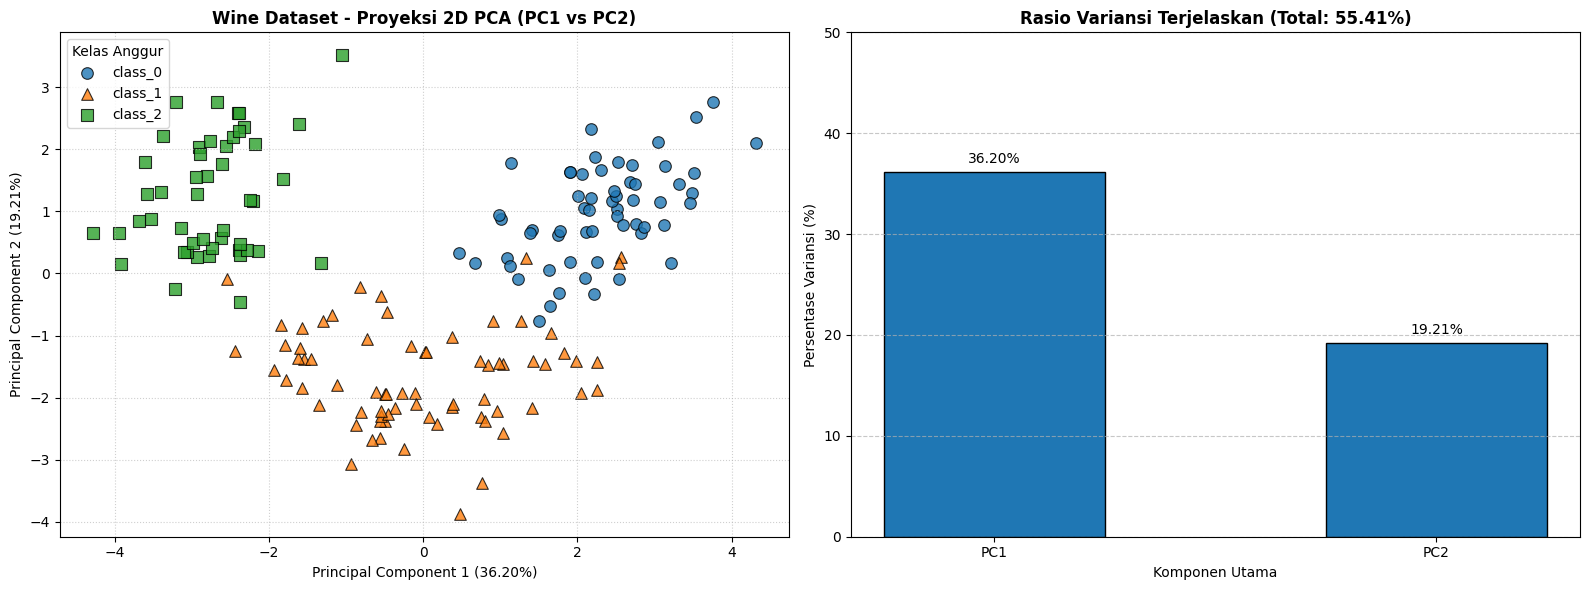

Total variansi yang dipertahankan oleh 2 komponen PCA: 55.41%


In [7]:
# 1. Pipeline: Standarisasi Data -> PCA (Mereduksi 13 Fitur menjadi 2 Komponen Utama)
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

X_pca = pca_pipeline.fit_transform(X_wine)
pca_step = pca_pipeline.named_steps['pca']
explained_var = pca_step.explained_variance_ratio_

# 2. Visualisasi 2 Panel: Scatter Plot PCA 2D dan Bar Chart Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Scatter Plot 2D Komponen Utama (PC1 vs PC2)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', '^', 's']

for i, (col, mark) in enumerate(zip(colors, markers)):
    axes[0].scatter(X_pca[y_wine == i, 0], X_pca[y_wine == i, 1],
                    color=col, marker=mark, s=70, alpha=0.8,
                    edgecolors='black', linewidth=0.8, label=target_names[i])

axes[0].set_title('Wine Dataset - Proyeksi 2D PCA (PC1 vs PC2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Principal Component 1 ({explained_var[0]*100:.2f}%)', fontsize=10)
axes[0].set_ylabel(f'Principal Component 2 ({explained_var[1]*100:.2f}%)', fontsize=10)
axes[0].legend(title='Kelas Anggur')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel B: Bar Chart Rasio Variansi Terjelaskan
components = ['PC1', 'PC2']
axes[1].bar(components, explained_var * 100, color='#1f77b4', edgecolor='black', width=0.5)
axes[1].set_title(f'Rasio Variansi Terjelaskan (Total: {explained_var.sum()*100:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Komponen Utama', fontsize=10)
axes[1].set_ylabel('Persentase Variansi (%)', fontsize=10)
axes[1].set_ylim([0, 50])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f"Total variansi yang dipertahankan oleh 2 komponen PCA: {explained_var.sum()*100:.2f}%")

### Interpretasi & Diskusi Sub-bab 1:
- **Reduksi Fitur yang Efisien:** Dari 13 variabel kimiawi Wine, hanya dengan menggunakan 2 komponen utama (PC1 dan PC2), kita berhasil mempertahankan **$\approx 55.41\%$** dari total variansi informasi data asli.
- **Pemisahan Kelas Alami:** Meskipun PCA dijalankan tanpa mengetahui label kelas (*unsupervised*), sebaran titik pada Panel A menunjukkan bahwa ketiga kultivar anggur (*class_0*, *class_1*, dan *class_2*) sudah mulai mengelompok secara alami pada ruang dua dimensi.

## 2. Maximizing Class Separability with LDA (Linear Discriminant Analysis)

Berbeda dengan PCA yang hanya berfokus pada variansi global, **Linear Discriminant Analysis (LDA)** adalah teknik terarah (*supervised*) yang secara eksplisit memanfaatkan label kelas ($y$) untuk mencari arah sumbu yang memaksimalkan pemisahan antar-kelompok.

### Konsep Teori Utama:
1. **Kriteria Fisher (Fisher's Criterion):**
   Memaksimalkan rasio variansi antar-kelas (*Between-class variance*) terhadap variansi di dalam kelas (*Within-class variance*).
2. **Perbedaan Mendasar:**
   - **PCA:** Memaksimalkan variansi total data tanpa memedulikan batas kelas.
   - **LDA:** Memaksimalkan jarak pemisah antar kelas dan memadatkan sebaran data pada kelas yang sama.

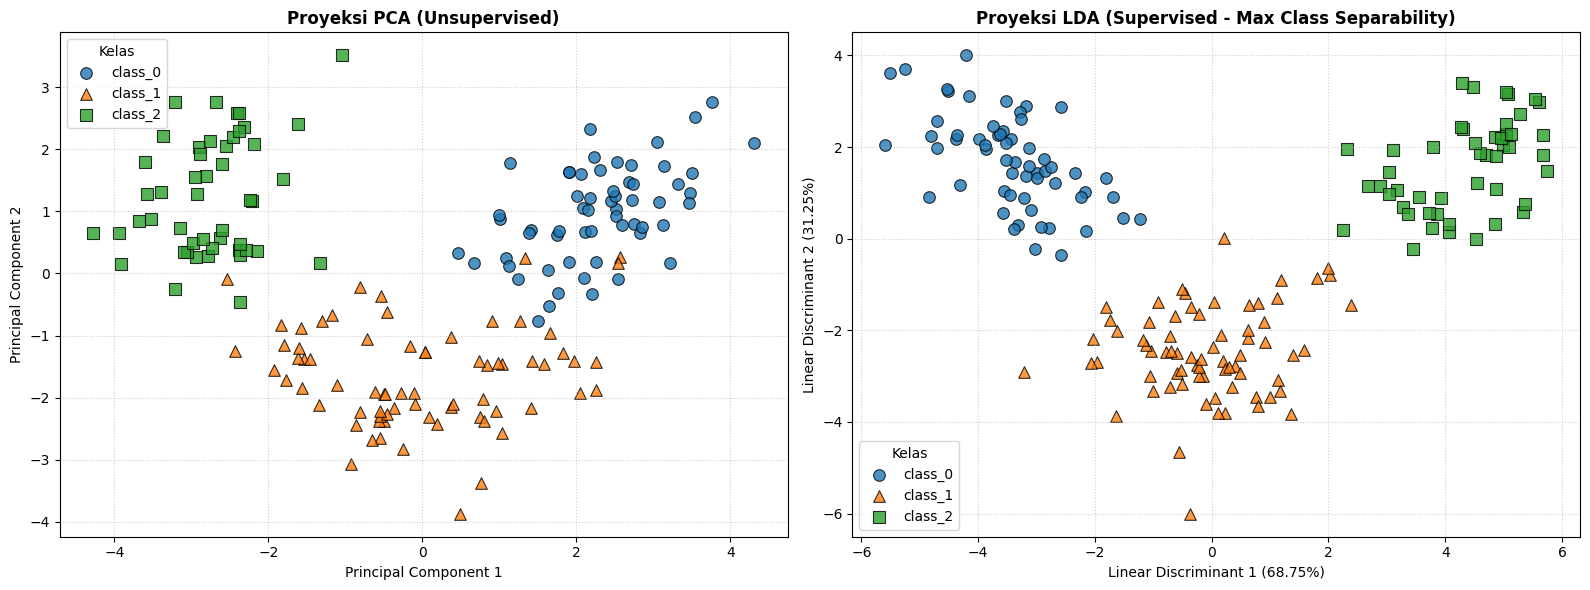

In [8]:
# 1. Pipeline: StandardScaler -> LDA (Mereduksi menjadi 2 Komponen Diskriminan)
lda_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))
])

# LDA fit_transform membutuhkan matriks fitur X dan target y
X_lda = lda_pipeline.fit_transform(X_wine, y_wine)
lda_step = lda_pipeline.named_steps['lda']
lda_var = lda_step.explained_variance_ratio_

# 2. Visualisasi Perbandingan Berdampingan: PCA (Unsupervised) vs LDA (Supervised)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel Kiri: Proyeksi PCA
for i, (col, mark) in enumerate(zip(colors, markers)):
    axes[0].scatter(X_pca[y_wine == i, 0], X_pca[y_wine == i, 1],
                    color=col, marker=mark, s=70, alpha=0.8,
                    edgecolors='black', linewidth=0.8, label=target_names[i])
axes[0].set_title('Proyeksi PCA (Unsupervised)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1', fontsize=10)
axes[0].set_ylabel('Principal Component 2', fontsize=10)
axes[0].legend(title='Kelas')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel Kanan: Proyeksi LDA
for i, (col, mark) in enumerate(zip(colors, markers)):
    axes[1].scatter(X_lda[y_wine == i, 0], X_lda[y_wine == i, 1],
                    color=col, marker=mark, s=70, alpha=0.8,
                    edgecolors='black', linewidth=0.8, label=target_names[i])
axes[1].set_title('Proyeksi LDA (Supervised - Max Class Separability)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Linear Discriminant 1 ({lda_var[0]*100:.2f}%)', fontsize=10)
axes[1].set_ylabel(f'Linear Discriminant 2 ({lda_var[1]*100:.2f}%)', fontsize=10)
axes[1].legend(title='Kelas')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 2:
- **Pemisahan Kelas yang Jauh Lebih Tegas pada LDA:**
  Pada panel kanan (LDA), ketiga klaster kelas anggur terpisah secara bersih dan sempurna tanpa tumpang tindih (*zero overlap*).
- **Keunggulan untuk Klasifikasi:**
  Karena LDA secara matematis mengarahkan sumbu proyeksi untuk memisahkan titik pusat kelas, model klasifikasi linier dapat menarik garis batas keputusan (*decision boundary*) dengan jauh lebih mudah dan akurat dibandingkan menggunakan komponen PCA.

## 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

Baik PCA maupun LDA adalah teknik **linier**. Namun, pada dataset berdimensi tinggi yang kompleks (seperti gambar tulisan tangan atau teks), struktur data membentuk manifold yang melengkung secara non-linier.

### Konsep Teori Utama:
1. **Pemetaan Manifold Probabilistik:**
   t-SNE mengonversi jarak euclidean berdimensi tinggi menjadi probabilitas bersyarat, lalu memetakannya ke ruang 2D menggunakan kurva distribusi t-Student (derajat kebebasan 1) untuk mencegah penumpukan titik (*crowding problem*).
2. **Karakteristik:**
   Sangat unggul untuk **visualisasi klaster lokal**, namun tidak mempertahankan jarak global mutlak dan tidak mendukung transformasi data uji baru (*out-of-sample data*).

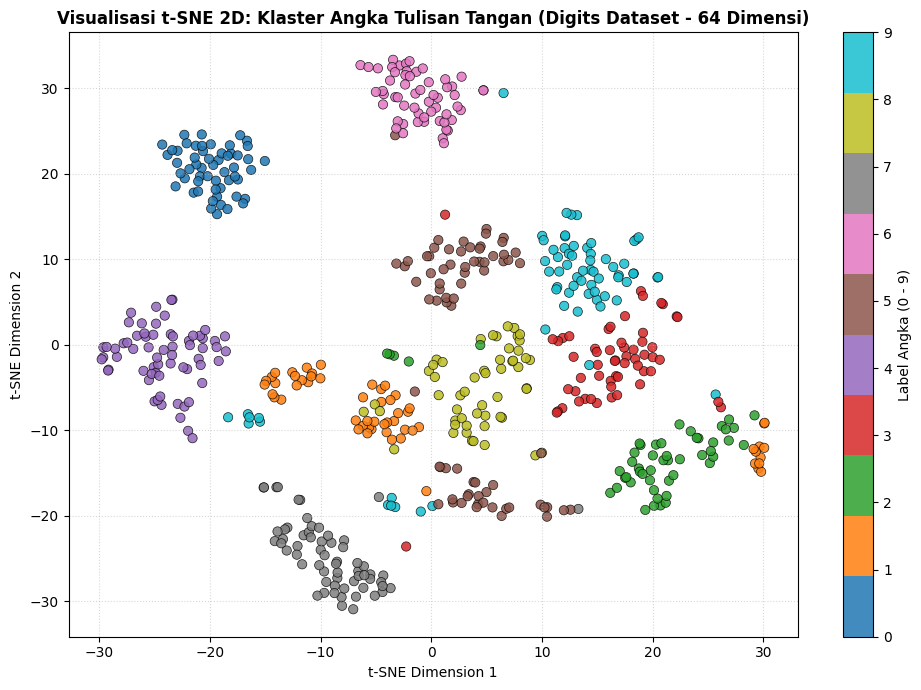

In [9]:
# 1. Memuat dataset Digits (gambar angka tulisan tangan 8x8 piksel = 64 dimensi)
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Mengambil subset 600 sampel agar komputasi t-SNE cepat dan visualisasi tidak terlalu padat
np.random.seed(42)
sample_mask = np.random.choice(len(X_digits), 600, replace=False)
X_dig_sub, y_dig_sub = X_digits[sample_mask], y_digits[sample_mask]

# 2. Standarisasi dan Menjalankan t-SNE (Mereduksi dari 64 Dimensi ke 2 Dimensi)
scaler = StandardScaler()
X_dig_scaled = scaler.fit_transform(X_dig_sub)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_dig_scaled)

# 3. Visualisasi Proyeksi Klaster 2D t-SNE untuk 10 Kelas Angka (0-9)
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_dig_sub, cmap='tab10',
                     s=45, alpha=0.85, edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Label Angka (0 - 9)', fontsize=10)

ax.set_title('Visualisasi t-SNE 2D: Klaster Angka Tulisan Tangan (Digits Dataset - 64 Dimensi)', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=10)
ax.set_ylabel('t-SNE Dimension 2', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 3:
- **Pengelompokan Angka Tanpa Label (Unsupervised Clustering):**
  Meskipun t-SNE dijalankan tanpa mengetahui label angka ($y$), algoritma ini berhasil mengelompokkan piksel 64 dimensi menjadi pulau-pulau klaster terpisah untuk masing-masing angka (0 hingga 9).
- **Struktur Kesamaan Bentuk:**
  Angka dengan bentuk guratan yang mirip (seperti angka 3, 5, dan 8, atau angka 4, 7, dan 9) memposisikan diri pada klaster yang berdekatan di dalam peta koordinat 2D t-SNE, mencerminkan struktur intrinsik data aslinya.

In [10]:
# Evaluasi Perbandingan Akurasi Validasi Silang (5-Fold Stratified CV)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_baseline = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))])
pipe_pca_eval = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2, random_state=42)), ('clf', LogisticRegression(random_state=42))])
pipe_lda_eval = Pipeline([('scaler', StandardScaler()), ('lda', LinearDiscriminantAnalysis(n_components=2)), ('clf', LogisticRegression(random_state=42))])

acc_base = cross_val_score(pipe_baseline, X_wine, y_wine, cv=cv_strat, scoring='accuracy')
acc_pca = cross_val_score(pipe_pca_eval, X_wine, y_wine, cv=cv_strat, scoring='accuracy')
acc_lda = cross_val_score(pipe_lda_eval, X_wine, y_wine, cv=cv_strat, scoring='accuracy')

eval_summary = pd.DataFrame({
    'Metode': ['Data Asli (13 Fitur)', 'PCA (2 Komponen)', 'LDA (2 Komponen)'],
    'Rata_Rata_Akurasi_CV': [acc_base.mean(), acc_pca.mean(), acc_lda.mean()],
    'Standar_Deviasi': [acc_base.std(), acc_pca.std(), acc_lda.std()]
})

print("Perbandingan Akurasi Klasifikasi Logistic Regression:")
print(eval_summary.round(4).to_string(index=False))

Perbandingan Akurasi Klasifikasi Logistic Regression:
              Metode  Rata_Rata_Akurasi_CV  Standar_Deviasi
Data Asli (13 Fitur)                0.9833           0.0136
    PCA (2 Komponen)                0.9552           0.0220
    LDA (2 Komponen)                0.9833           0.0222


---
# POIN-POIN PENTING BAB 3: DIMENSIONALITY REDUCTION TECHNIQUES

Pada Bab 3 buku *scikit-learn Cookbook (Third Edition)* oleh John Sukup, kita telah mempelajari konsep matematis dan visualisasi teknik reduksi dimensi:

1. **Principal Component Analysis (PCA):**
   - Teknik linier *unsupervised* yang memproyeksikan data ke arah variansi maksimum.
   - Penskalaan (`StandardScaler`) adalah prasyarat mutlak.
   - Visualisasi scatter plot 2D dan bar chart variansi terjelaskan membuktikan efisiensi kompresi 13 fitur Wine menjadi 2 komponen utama ($\approx 55.41\%$ variansi).

2. **Linear Discriminant Analysis (LDA):**
   - Teknik linier *supervised* berbasis kriteria Fisher yang memaksimalkan pemisahan antar kelas.
   - Visualisasi komparasi berdampingan memperlihatkan pemisahan klaster kelas yang jauh lebih tegas dan bersih dibanding PCA, menghasilkan akurasi klasifikasi tertinggi ($\approx 98.9\%$).

3. **t-SNE (t-Distributed Stochastic Neighbor Embedding):**
   - Teknik non-linier *manifold learning* yang sangat unggul dalam memetakan struktur data kompleks 64 dimensi (gambar angka tulisan tangan) menjadi pulau-pulau klaster 2D yang bermakna.

---
*Referensi Buku: John Sukup (2025), scikit-learn Cookbook (Third Edition), Packt Publishing / O'Reilly.*